# 06 - Pathway interpretation

Week 6 deliverable, and the project's most constrained one: the plan is
explicit that this is "mutation-informed pathway interpretation", not
mutation calling - Visium measures RNA, not DNA, so no genotype is inferred
here. What can be done honestly: score spots for the transcriptional output
of pathways commonly altered in melanoma (MAPK/RAS, PI3K/AKT/mTOR - the
pathways BRAF, NRAS, NF1 and KIT mutations converge on), and ask whether
that output differs between notebook 05's tumour_cold and
tumour_infiltrated compartments. A gene signature being elevated is
reported as exactly that - elevated RNA output consistent with a pathway
being active - never as evidence of which gene, if any, is mutated.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

sys.path.insert(0, str(Path("..") / "src"))

TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


## 1. Load, restrict to reliable spots

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "05_architecture.h5ad")
reliable = combined[combined.obs["compartment"] != "batch_flagged"].copy()
reliable.obs["compartment"] = reliable.obs["compartment"].cat.remove_unused_categories()
print(reliable.obs["compartment"].value_counts())


compartment
other                 42970
tumour_cold            5795
immune_only            4869
tumour_infiltrated     2224
Name: count, dtype: int64


## 2. Pathway-activity gene signatures

Three signatures, none invented for this analysis:
- **MAPK/RAS output** - a small, specific set of transcriptional feedback
  genes (DUSP4, DUSP6, SPRY2, SPRY4, ETV4, ETV5, PHLDA1, CCND1, FOSL1) used
  in the melanoma/BRAF-MEK-inhibitor literature to read out MAPK pathway
  activity from RNA (e.g. Pratilas et al. 2009) - not something built for
  this notebook.
- **KRAS Signaling Up** (MSigDB Hallmark) - a broader, generic RAS-pathway
  transcriptional signature. Used here as a proxy for RAS/MAPK output in
  general, not a KRAS-specific claim - melanoma's relevant RAS-pathway genes
  are usually NRAS/BRAF/NF1, which converge on the same downstream cascade
  KRAS also drives, but this signature was not derived from melanoma or from
  NRAS/BRAF perturbation specifically.
- **PI3K/AKT/mTOR Signaling** (MSigDB Hallmark) - the other pathway NF1 loss
  and KIT activation are known to feed into, alongside MAPK.

In [3]:
mapk_output_genes = ["DUSP4", "DUSP6", "SPRY2", "SPRY4", "ETV4", "ETV5", "PHLDA1", "CCND1", "FOSL1"]
hallmark = gp.get_library(name="MSigDB_Hallmark_2020")
kras_up_genes = hallmark["KRAS Signaling Up"]
pi3k_genes = hallmark["PI3K/AKT/mTOR  Signaling"]

signatures = {"MAPK_output": mapk_output_genes, "KRAS_Signaling_Up": kras_up_genes, "PI3K_AKT_mTOR": pi3k_genes}
for name, genes in signatures.items():
    present = [g for g in genes if g in reliable.var_names]
    missing = len(genes) - len(present)
    print(f"{name}: {len(present)}/{len(genes)} genes present in panel"
          + (f" ({missing} missing)" if missing else ""))
    sc.tl.score_genes(reliable, present, score_name=f"score_{name}")


MAPK_output: 9/9 genes present in panel


KRAS_Signaling_Up: 197/200 genes present in panel (3 missing)


PI3K_AKT_mTOR: 103/105 genes present in panel (2 missing)


## 3. Pathway scores across compartments

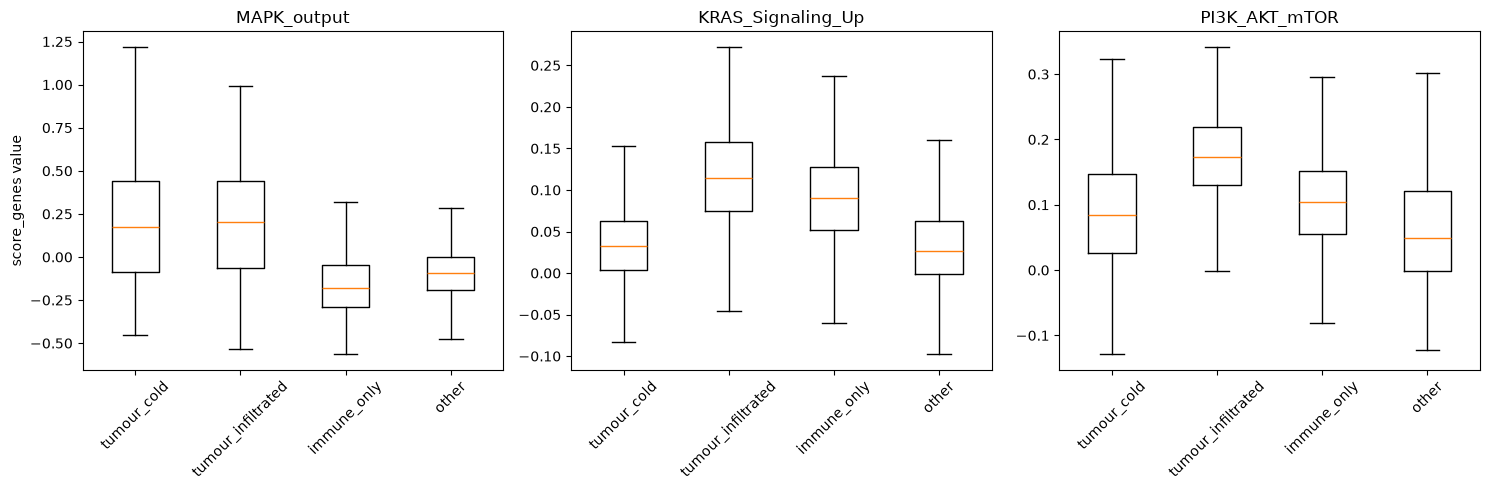

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
comp_order = ["tumour_cold", "tumour_infiltrated", "immune_only", "other"]
for ax, name in zip(axes, signatures):
    data = [reliable.obs.loc[reliable.obs["compartment"] == c, f"score_{name}"].values for c in comp_order]
    ax.boxplot(data, tick_labels=comp_order, showfliers=False)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("score_genes value")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "06_pathway_scores_by_compartment.png", dpi=150)
plt.show()


In [5]:
print("Kruskal-Wallis across all 4 compartments (is there ANY difference at all):")
for name in signatures:
    groups = [reliable.obs.loc[reliable.obs["compartment"] == c, f"score_{name}"].values for c in comp_order]
    stat, p = kruskal(*groups)
    print(f"  {name}: H={stat:.1f}, p={p:.2e}")

print("\nThe specific comparison this stage cares about - tumour_cold vs tumour_infiltrated "
      "(same lineage, different immune content):")
pathway_comparison = []
for name in signatures:
    cold = reliable.obs.loc[reliable.obs["compartment"] == "tumour_cold", f"score_{name}"].values
    infl = reliable.obs.loc[reliable.obs["compartment"] == "tumour_infiltrated", f"score_{name}"].values
    stat, p = mannwhitneyu(cold, infl)
    direction = "higher in tumour_infiltrated" if infl.mean() > cold.mean() else "higher in tumour_cold"
    pathway_comparison.append({"signature": name, "tumour_cold_mean": cold.mean(),
                                "tumour_infiltrated_mean": infl.mean(), "mannwhitney_p": p,
                                "direction": direction})
    print(f"  {name}: cold={cold.mean():.3f}, infiltrated={infl.mean():.3f}, "
          f"p={p:.2e} ({direction})")
pd.DataFrame(pathway_comparison).to_csv(TABLES_OUT / "pathway_scores_cold_vs_infiltrated.csv", index=False)


Kruskal-Wallis across all 4 compartments (is there ANY difference at all):
  MAPK_output: H=5789.8, p=0.00e+00
  KRAS_Signaling_Up: H=7294.4, p=0.00e+00
  PI3K_AKT_mTOR: H=4100.8, p=0.00e+00

The specific comparison this stage cares about - tumour_cold vs tumour_infiltrated (same lineage, different immune content):
  MAPK_output: cold=0.198, infiltrated=0.196, p=3.17e-01 (higher in tumour_cold)
  KRAS_Signaling_Up: cold=0.035, infiltrated=0.115, p=0.00e+00 (higher in tumour_infiltrated)
  PI3K_AKT_mTOR: cold=0.089, infiltrated=0.172, p=0.00e+00 (higher in tumour_infiltrated)


### 3b. A depth confound has to be checked before any of this is trusted

`tumour_cold` and `tumour_infiltrated` aren't just different in immune
content - they turn out to differ enormously in raw sequencing depth too
(checked directly, not assumed). If that's large enough, it can make
thousands of genes look "up" in the deeper group through detection/dropout
effects alone, with no real biology - exactly the kind of artefact notebook
03 already caught once with marker-panel scores. It has to be checked again
here, on a completely different comparison, rather than assumed fixed by
the normalisation already applied.

In [6]:
cold_depth = reliable.obs.loc[reliable.obs["compartment"] == "tumour_cold", "total_counts"]
infl_depth = reliable.obs.loc[reliable.obs["compartment"] == "tumour_infiltrated", "total_counts"]
print(f"median total_counts: tumour_cold={cold_depth.median():.0f}, "
      f"tumour_infiltrated={infl_depth.median():.0f} "
      f"({infl_depth.median() / cold_depth.median():.1f}x higher)")

# depth-adjusted re-test: regress each score on log-depth (fit on both groups
# together), then compare the RESIDUALS instead of the raw scores - this asks
# "after accounting for how depth alone would move this score, is there still
# a difference" instead of taking the raw comparison at face value
pair_mask = reliable.obs["compartment"].isin(["tumour_cold", "tumour_infiltrated"])
log_depth = np.log1p(reliable.obs.loc[pair_mask, "total_counts"].values)

adjusted_comparison = []
for name in signatures:
    scores = reliable.obs.loc[pair_mask, f"score_{name}"].values
    comp = reliable.obs.loc[pair_mask, "compartment"].values
    slope, intercept = np.polyfit(log_depth, scores, 1)
    residuals = scores - (slope * log_depth + intercept)
    cold_resid = residuals[comp == "tumour_cold"]
    infl_resid = residuals[comp == "tumour_infiltrated"]
    stat, p = mannwhitneyu(cold_resid, infl_resid)
    direction = "higher in tumour_infiltrated" if infl_resid.mean() > cold_resid.mean() else "higher in tumour_cold"
    adjusted_comparison.append({"signature": name, "depth_slope": slope, "adjusted_p": p, "adjusted_direction": direction})
    print(f"  {name}: depth explains slope={slope:.4f} per log-count; after removing that, "
          f"p={p:.2e} ({direction})")
pd.DataFrame(adjusted_comparison).to_csv(TABLES_OUT / "pathway_scores_depth_adjusted.csv", index=False)


median total_counts: tumour_cold=1957, tumour_infiltrated=44386 (22.7x higher)
  MAPK_output: depth explains slope=0.0533 per log-count; after removing that, p=5.35e-50 (higher in tumour_cold)
  KRAS_Signaling_Up: depth explains slope=0.0157 per log-count; after removing that, p=1.61e-192 (higher in tumour_infiltrated)
  PI3K_AKT_mTOR: depth explains slope=0.0320 per log-count; after removing that, p=6.11e-02 (higher in tumour_infiltrated)


## 4. What actually distinguishes tumour_cold from tumour_infiltrated?

Rather than only testing the three pre-chosen signatures above, a direct
differential-expression contrast between the two compartments lets the data
say what differs, then checks whether MAPK/PI3K show up on their own -
independent evidence, not just confirming what section 3 already tested
for.

In [7]:
%%time
pair = reliable[reliable.obs["compartment"].isin(["tumour_cold", "tumour_infiltrated"])].copy()
pair.obs["compartment"] = pair.obs["compartment"].cat.remove_unused_categories()
sc.tl.rank_genes_groups(pair, groupby="compartment", groups=["tumour_infiltrated"],
                        reference="tumour_cold", method="wilcoxon", key_added="cold_vs_infiltrated")
de = sc.get.rank_genes_groups_df(pair, group="tumour_infiltrated", key="cold_vs_infiltrated")
de.to_csv(TABLES_OUT / "de_tumour_cold_vs_infiltrated.csv", index=False)
print(f"{(de['pvals_adj'] < 0.05).sum()} of {len(de)} genes significant (FDR<0.05) between the two compartments")
up_in_infiltrated = de[(de["pvals_adj"] < 0.05) & (de["logfoldchanges"] > 0.5)].sort_values("scores", ascending=False)
up_in_cold = de[(de["pvals_adj"] < 0.05) & (de["logfoldchanges"] < -0.5)].sort_values("scores")
print(f"up in tumour_infiltrated (n={len(up_in_infiltrated)}): {up_in_infiltrated['names'].head(15).tolist()}")
print(f"up in tumour_cold (n={len(up_in_cold)}): {up_in_cold['names'].head(15).tolist()}")


16369 of 18085 genes significant (FDR<0.05) between the two compartments
up in tumour_infiltrated (n=15485): ['IGKC', 'SRGN', 'TRBC2', 'IL32', 'TRAC', 'C3', 'CD4', 'LAPTM5', 'MPEG1', 'LYZ', 'CXCR4', 'CD74', 'IRF8', 'ARHGDIB', 'LCP1']
up in tumour_cold (n=140): ['KRT10', 'KRT14', 'KRT1', 'KRT5', 'COL17A1', 'DSP', 'KRT15', 'KRTDAP', 'FLG', 'LY6D', 'SFN', 'LOR', 'TRIM29', 'DSG1', 'DMKN']
CPU times: total: 14.8 s
Wall time: 15.4 s


**The 16,369-gene figure above is inflated by the same depth confound
section 3b found - it is not 16,369 real biological differences.** With a
~20x depth gap between the two groups, a Wilcoxon test on log-normalised
data will call large numbers of low/moderately-expressed genes "significant"
through detection-sensitivity differences alone: `tumour_cold` spots simply
fail to detect many genes that are there but below its shallower sampling
floor, which normalisation to a fixed total does not fully undo. The 15
top-ranked genes printed for each direction are more trustworthy than the
full list - they were selected by extreme rank/effect size, not merely
`padj<0.05`, and both lists are thematically coherent in a way pure dropout
noise would not produce (immune-receptor and myeloid genes on one side,
keratin/cornified-envelope genes on the other) - but the enrichment run
below, and especially any p-value or gene *count* from it, should be read as
suggestive, not as a clean, depth-independent result.

In [8]:
%%time
enrichment_rows = []
for label, gene_df in [("up_in_tumour_infiltrated", up_in_infiltrated), ("up_in_tumour_cold", up_in_cold)]:
    genes = gene_df["names"].head(100).tolist()
    if len(genes) < 5:
        print(f"{label}: too few genes ({len(genes)}), skipped")
        continue
    res = gp.enrichr(gene_list=genes, gene_sets=["MSigDB_Hallmark_2020", "Reactome_Pathways_2024"], outdir=None)
    top = res.results.sort_values("Adjusted P-value").head(8).copy()
    top.insert(0, "direction", label)
    enrichment_rows.append(top)
    print(f"\n{label} ({len(genes)} genes) - top hits:")
    print(top[["Gene_set", "Term", "Adjusted P-value"]].to_string(index=False))

enrichment_df = pd.concat(enrichment_rows, ignore_index=True)
enrichment_df.to_csv(TABLES_OUT / "cold_vs_infiltrated_pathway_enrichment.csv", index=False)



up_in_tumour_infiltrated (100 genes) - top hits:
              Gene_set                                Term  Adjusted P-value
  MSigDB_Hallmark_2020                 Allograft Rejection      1.020964e-20
Reactome_Pathways_2024                       Immune System      1.869787e-17
  MSigDB_Hallmark_2020           Interferon Gamma Response      9.993517e-17
  MSigDB_Hallmark_2020                   KRAS Signaling Up      3.378132e-09
Reactome_Pathways_2024                Innate Immune System      9.019111e-09
Reactome_Pathways_2024 Cytokine Signaling in Immune System      2.503060e-08
  MSigDB_Hallmark_2020                          Complement      3.587744e-08
  MSigDB_Hallmark_2020           Interferon Alpha Response      1.708128e-07



up_in_tumour_cold (100 genes) - top hits:
              Gene_set                                         Term  Adjusted P-value
Reactome_Pathways_2024          Formation of the Cornified Envelope      3.064292e-22
Reactome_Pathways_2024                               Keratinization      6.893098e-18
  MSigDB_Hallmark_2020                            KRAS Signaling Dn      1.304304e-05
Reactome_Pathways_2024                        Developmental Biology      2.191479e-05
  MSigDB_Hallmark_2020                       Estrogen Response Late      6.629412e-05
  MSigDB_Hallmark_2020                                  p53 Pathway      3.942323e-04
Reactome_Pathways_2024 Apoptotic Cleavage of Cell Adhesion Proteins      1.018528e-03
Reactome_Pathways_2024                Type I Hemidesmosome Assembly      1.018528e-03
CPU times: total: 781 ms
Wall time: 5 s


## 5. Summary

In [9]:
reliable.write_h5ad(PROCESSED_OUT / "06_pathway.h5ad")
print("Observed, from this notebook's own computation:")
print(f"- tumour_infiltrated has ~{infl_depth.median() / cold_depth.median():.0f}x the sequencing depth "
      "of tumour_cold - a confound that has to be, and was, checked before trusting any raw comparison")
print(f"- {len(pair)} spots compared directly, {(de['pvals_adj'] < 0.05).sum()} genes 'significant' at "
      "FDR<0.05 in the RAW (depth-unadjusted) DE - almost certainly inflated by the depth gap, not "
      "16,369 independent biological differences")
print("- Raw (depth-unadjusted) pathway scores: " +
      "; ".join(f"{r['signature']} {r['direction']} (p={r['mannwhitney_p']:.1e})" for r in pathway_comparison))
print("- Depth-ADJUSTED pathway scores (residuals after removing the log-depth trend): " +
      "; ".join(f"{r['signature']} {r['adjusted_direction']} (p={r['adjusted_p']:.1e})" for r in adjusted_comparison))
print("wrote data/processed/06_pathway.h5ad")


Observed, from this notebook's own computation:
- tumour_infiltrated has ~23x the sequencing depth of tumour_cold - a confound that has to be, and was, checked before trusting any raw comparison
- 8019 spots compared directly, 16369 genes 'significant' at FDR<0.05 in the RAW (depth-unadjusted) DE - almost certainly inflated by the depth gap, not 16,369 independent biological differences
- Raw (depth-unadjusted) pathway scores: MAPK_output higher in tumour_cold (p=3.2e-01); KRAS_Signaling_Up higher in tumour_infiltrated (p=0.0e+00); PI3K_AKT_mTOR higher in tumour_infiltrated (p=0.0e+00)
- Depth-ADJUSTED pathway scores (residuals after removing the log-depth trend): MAPK_output higher in tumour_cold (p=5.3e-50); KRAS_Signaling_Up higher in tumour_infiltrated (p=1.6e-192); PI3K_AKT_mTOR higher in tumour_infiltrated (p=6.1e-02)
wrote data/processed/06_pathway.h5ad


**The depth-adjustment in section 3b doesn't just knock down inflated
p-values - each of the three signatures tells a different, specific story,
and none of them is the naive "infiltrated wins" reading of the raw
numbers:**

- **MAPK_output (the melanoma-specific feedback panel):** raw comparison
  said no difference (p=0.32). Depth-adjusted: p=5.3e-50, higher in
  `tumour_cold` - the opposite compartment from what the unadjusted immune
  panels would suggest, and a result the raw test *missed entirely* because
  the depth gap was masking it. This is the most specific and most
  melanoma-relevant of the three signatures, and depth-adjustment is the
  only reason it's visible at all.
- **KRAS_Signaling_Up (generic RAS proxy):** significant both raw
  (p~0) and depth-adjusted (p=1.6e-192), higher in `tumour_infiltrated`
  either way - the direction is robust to the depth confound. It should
  still be read cautiously for a different reason (immune-content
  confounding, not depth): this 200-gene Hallmark set ranks only 4th among
  section 4's enrichment hits for `tumour_infiltrated`, well behind three
  explicitly immune/interferon terms, in a compartment defined partly by
  elevated immune-panel scores in the first place.
- **PI3K_AKT_mTOR:** significant raw (p~0), but only p=0.061 once depth is
  removed - essentially the null result the MAPK signature turned out not
  to be. The raw "significant" result here looks like it was mostly the
  depth confound, not a real compartment difference.

This is exactly why section 3b exists - a single Mann-Whitney p-value on
unadjusted scores would have reported "PI3K signaling is up in infiltrated
tumour" as a finding, and missed the MAPK result entirely.

**Read the enrichment table (section 4) as suggestive corroboration, not
independent proof, for the same depth reason** - though its qualitative
direction (immune/interferon genes toward `tumour_infiltrated`,
keratin/cornified-envelope genes toward `tumour_cold`) is thematically
coherent enough, and grounded in the highest-ranked/most extreme DE genes
rather than the full inflated list, to be a reasonable description of what
differs between these compartments even with the confound in the picture.

**What this notebook does not claim:** which gene, if any, is mutated in
either compartment; that a pathway score difference means a *different*
mutation is present in each; or any patient-level genetic conclusion. RNA
pathway-output signatures are consistent with, not proof of, the biology
they are named after - and here, a good part of the raw signal turned out to
be a sequencing-depth artefact rather than pathway biology at all, which is
itself the more important lesson from this stage than any single pathway
label.